# Mangrove transect topography reconstruction (Google Drive version)

Reconstructs the 3D path (X, Y, Z) of a mangrove transect from a CSV of
points along a metered tape (distance + inclination per point, with an
optional RTK GNSS fix on any point — mandatory only at the start). This
version reads the input CSV directly from **Google Drive** and writes the
results into a subfolder next to it, named after the input file.

**Setup, once:**
1. Put this notebook and your transect CSV(s) in the same Google Drive
   folder.
2. Set `DRIVE_FOLDER` below to that folder's path relative to "My Drive"
   (e.g. `"SEASTRONG/mangrove_transects"`).
3. Set `INPUT_CSV_NAME` to the CSV you want to process.
4. Run all cells. The first code cell will prompt you to authorize Drive
   access the first time.

A demo file, `transect_demo.csv`, is provided alongside this notebook —
upload it to the same Drive folder to try the notebook out before using your
own data; it matches the schema below exactly.

**CSV schema** — one row per point along the tape:

| column | required? | meaning |
|---|---|---|
| `tape_distance_m` | always | cumulative reading on the tape at this point (not segment length) |
| `inclination_deg` | all rows except the first | inclination of the segment *ending* at this point (+ up landward, − down landward) |
| `lat`, `lon` | only row 0 (others optional) | GNSS fix, decimal degrees WGS84 |
| `z` | only row 0 (others optional) | GNSS elevation, same datum throughout |
| `label` | optional | free text, carried through to the output |

**Method:** raw traverse from slope distance + inclination (or horizontal
distance + inclination, see `DISTANCE_IS_SLOPE`), then every row with a GNSS
fix becomes a "tie" the traverse is snapped to — misclosure between
consecutive ties is distributed proportionally along that stretch; points
past the last tie carry that tie's correction forward as a constant offset.

**Output:** a new folder next to the input CSV, named after it (e.g.
`transect_demo.csv` → `transect_demo/`), containing the results table (CSV)
and a profile + plan-view plot (PNG).

In [1]:
# Install/import dependencies (safe to re-run)
!pip install -q pyproj

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer, CRS

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/Othercomputers"
else:
    # Running outside Colab: treat DRIVE_FOLDER as a plain local path instead.
    DRIVE_ROOT = "."

print("Running in Colab:", IN_COLAB)
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Running in Colab: True
Drive root: /content/drive/Othercomputers


## 1. Configuration

- `DRIVE_FOLDER`: path to the folder (relative to "My Drive") containing this notebook and your CSV(s).
- `INPUT_CSV_NAME`: the CSV to process this run.
- `AZIMUTH_DEG`: compass bearing of the transect, pointing landward, degrees from **true north, clockwise**.
- `DISTANCE_IS_SLOPE`: `True` if tape readings follow the ground (slope distance, typical). `False` if already horizontal.
- `APPLY_TIE_ADJUSTMENT`: snap to GNSS ties and interpolate between them (recommended). `False` reports misclosures only, without correcting the points.

In [5]:
CONFIG = {
    "DRIVE_FOLDER": "My Mac/Documents/GitHub/seastrong-field-tools/Mangroves_topography",   # folder relative to My Drive, holding the notebook + CSVs
    "INPUT_CSV_NAME": "transect_demo.csv",            # CSV to process this run

    "AZIMUTH_DEG": 83.0,             # compass bearing landward, degrees from true north, clockwise
    "DISTANCE_IS_SLOPE": True,       # False if tape/instrument distances are already horizontal
    "APPLY_TIE_ADJUSTMENT": True,    # distribute misclosure between consecutive GNSS ties
}

folder = os.path.join(DRIVE_ROOT, CONFIG["DRIVE_FOLDER"])
input_path = os.path.join(folder, CONFIG["INPUT_CSV_NAME"])
base_name = os.path.splitext(CONFIG["INPUT_CSV_NAME"])[0]
output_dir = os.path.join(folder, base_name)

print("Input CSV: ", input_path)
print("Output dir:", output_dir)

Input CSV:  /content/drive/Othercomputers/My Mac/Documents/GitHub/seastrong-field-tools/Mangroves_topography/transect_demo.csv
Output dir: /content/drive/Othercomputers/My Mac/Documents/GitHub/seastrong-field-tools/Mangroves_topography/transect_demo


## 2. Load the points from Drive

In [6]:
def load_points(path):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Couldn't find {path}\n"
            f"Check that DRIVE_FOLDER and INPUT_CSV_NAME point at the right file, "
            f"and that Drive is mounted (see the first code cell)."
        )
    df = pd.read_csv(path)

    required = {"tape_distance_m", "inclination_deg"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing required column(s): {missing}. "
                          f"Found columns: {list(df.columns)}")
    for col in ("lat", "lon", "z", "label"):
        if col not in df.columns:
            df[col] = np.nan if col != "label" else ""
    return df


pts_df = load_points(input_path)
pts_df

,tape_distance_m,inclination_deg,lat,lon,z,label
0,0.0,0.10,44.180196,8.262852,0.0,start
1,1.0,0.35,NaN,NaN,NaN,NaN
2,2.0,3.00,NaN,NaN,NaN,NaN
3,3.0,-0.35,NaN,NaN,NaN,NaN
4,3.4,1.85,NaN,NaN,NaN,NaN
5,3.7,20.25,NaN,NaN,NaN,NaN
6,4.0,4.05,NaN,NaN,NaN,NaN
7,5.0,1.80,NaN,NaN,NaN,NaN
8,6.0,5.15,NaN,NaN,NaN,NaN
9,6.9,7.30,NaN,NaN,NaN,NaN


## 3. Validate and prepare the traverse

- Sort by `tape_distance_m`, reset the reference to the first row's reading.
- Row 0 must have `lat`, `lon`, `z` — it's the mandatory start point.
- Every row after the first must have `inclination_deg`.
- Distances must be strictly increasing (no duplicate/decreasing tape readings).

In [7]:
def prepare_points(df):
    df = df.sort_values("tape_distance_m").reset_index(drop=True)
    df["tape_distance_m"] = df["tape_distance_m"] - df["tape_distance_m"].iloc[0]

    if df[["lat", "lon", "z"]].iloc[0].isna().any():
        raise ValueError("Row 0 (the start point, tape_distance_m = minimum) must have lat, lon and z filled in.")

    missing_incl = df.index[df["inclination_deg"].isna()].tolist()
    missing_incl = [i for i in missing_incl if i != 0]
    if missing_incl:
        raise ValueError(f"inclination_deg is missing for row(s) {missing_incl}. "
                          f"Every point after the start needs an inclination value.")

    if not df["tape_distance_m"].is_monotonic_increasing or df["tape_distance_m"].duplicated().any():
        raise ValueError("tape_distance_m must be strictly increasing after sorting — "
                          "check for duplicate or out-of-order readings.")

    if "label" not in df.columns:
        df["label"] = ""
    df["label"] = df["label"].fillna("")
    return df


pts_df = prepare_points(pts_df)
tie_mask = pts_df[["lat", "lon", "z"]].notna().all(axis=1)
print(f"{tie_mask.sum()} GNSS tie point(s) found at row(s): {pts_df.index[tie_mask].tolist()}")
pts_df

1 GNSS tie point(s) found at row(s): [0]


,tape_distance_m,inclination_deg,lat,lon,z,label
0,0.0,0.10,44.180196,8.262852,0.0,start
1,1.0,0.35,NaN,NaN,NaN,
2,2.0,3.00,NaN,NaN,NaN,
3,3.0,-0.35,NaN,NaN,NaN,
4,3.4,1.85,NaN,NaN,NaN,
5,3.7,20.25,NaN,NaN,NaN,
6,4.0,4.05,NaN,NaN,NaN,
7,5.0,1.80,NaN,NaN,NaN,
8,6.0,5.15,NaN,NaN,NaN,
9,6.9,7.30,NaN,NaN,NaN,


## 4. Project to UTM and compute the raw (dead-reckoned) traverse

All math happens in UTM meters (zone auto-detected from the start point),
referenced entirely from the start point — this is the single consistent
baseline every tie's misclosure is measured against.

$$h_i = d_i\cos\theta_i,\quad v_i = d_i\sin\theta_i \quad\text{(slope distances)}$$
$$h_i = d_i,\quad v_i = d_i\tan\theta_i \quad\text{(horizontal distances)}$$
$$H_n=\sum_{i\le n} h_i,\qquad X_n = X_0+H_n\sin(\mathrm{az}),\qquad Y_n = Y_0+H_n\cos(\mathrm{az}),\qquad Z_n = Z_0+\sum_{i\le n} v_i$$

In [8]:
def utm_epsg_for(lat, lon):
    zone = int((lon + 180) / 6) + 1
    hemisphere = 326 if lat >= 0 else 327  # EPSG 326xx = N, 327xx = S
    return int(f"{hemisphere}{zone:02d}")

start_lat, start_lon, start_z = pts_df.loc[0, ["lat", "lon", "z"]]
epsg_utm = utm_epsg_for(start_lat, start_lon)
crs_wgs84 = CRS.from_epsg(4326)
crs_utm = CRS.from_epsg(epsg_utm)
to_utm = Transformer.from_crs(crs_wgs84, crs_utm, always_xy=True)
to_wgs84 = Transformer.from_crs(crs_utm, crs_wgs84, always_xy=True)

X0, Y0 = to_utm.transform(start_lon, start_lat)
Z0 = float(start_z)
print(f"UTM CRS: EPSG:{epsg_utm} ({crs_utm.name})")
print(f"Start point (UTM): X={X0:.3f}, Y={Y0:.3f}, Z={Z0:.3f}")


def compute_raw_traverse(df, X0, Y0, Z0, azimuth_deg, distance_is_slope):
    az = np.radians(azimuth_deg)
    seg_dist = df["tape_distance_m"].diff().to_numpy()[1:]           # segment lengths
    incl = np.radians(df["inclination_deg"].to_numpy()[1:])

    if distance_is_slope:
        h = seg_dist * np.cos(incl)
        v = seg_dist * np.sin(incl)
    else:
        h = seg_dist.copy()
        v = seg_dist * np.tan(incl)

    H = np.concatenate(([0.0], np.cumsum(h)))
    dZ = np.concatenate(([0.0], np.cumsum(v)))

    X_raw = X0 + H * np.sin(az)
    Y_raw = Y0 + H * np.cos(az)
    Z_raw = Z0 + dZ

    out = df.copy()
    out["H"] = H
    out["X_raw"] = X_raw
    out["Y_raw"] = Y_raw
    out["Z_raw"] = Z_raw
    return out


raw = compute_raw_traverse(pts_df, X0, Y0, Z0, CONFIG["AZIMUTH_DEG"], CONFIG["DISTANCE_IS_SLOPE"])
raw[["tape_distance_m", "H", "X_raw", "Y_raw", "Z_raw", "label"]]

UTM CRS: EPSG:32632 (WGS 84 / UTM zone 32N)
Start point (UTM): X=441078.928, Y=4892151.328, Z=0.000


,tape_distance_m,H,X_raw,Y_raw,Z_raw,label
0,0.0,0.000000,441078.927526,4.892151e+06,0.000000,start
1,1.0,0.999981,441079.920053,4.892151e+06,0.006109,
2,2.0,1.998611,441080.911239,4.892152e+06,0.058445,
3,3.0,2.998592,441081.903767,4.892152e+06,0.052336,
4,3.4,3.398384,441082.300578,4.892152e+06,0.065249,
5,3.7,3.679841,441082.579938,4.892152e+06,0.169084,
6,4.0,3.979092,441082.876958,4.892152e+06,0.190272,
7,5.0,4.978599,441083.869014,4.892152e+06,0.221683,
8,6.0,5.974562,441084.857554,4.892152e+06,0.311447,
9,6.9,6.867267,441085.743605,4.892152e+06,0.425805,


## 5. Multi-tie closure adjustment

For every tie point $k$ (a row with a GNSS fix), compute its misclosure
against the raw traverse: $C_k = (\text{measured}_k - \text{raw}_k)$. Row 0's
misclosure is always zero by construction.

For a point $i$ between two consecutive ties $k$ and $k{+}1$, interpolate the
correction by its fractional position (in cumulative distance) between them:

$$\text{corrected}_i = \text{raw}_i + C_k + \frac{H_i-H_k}{H_{k+1}-H_k}\,(C_{k+1}-C_k)$$

For points **beyond the last tie** (no further known point to close
against), the last tie's correction $C_{\text{last}}$ is carried forward as a
constant offset — the best available estimate, since there's no information
on how error grows past that point.

If there's only one tie (the mandatory start point), this reduces to no
adjustment at all — identical to the plain dead-reckoned traverse.

In [9]:
def utm_of_row(row):
    x, y = to_utm.transform(row["lon"], row["lat"])
    return x, y, row["z"]


tie_idx = raw.index[tie_mask].tolist()

# misclosure vector at each tie, measured against the single raw traverse
C = {}
for k in tie_idx:
    x_meas, y_meas, z_meas = utm_of_row(raw.loc[k])
    C[k] = np.array([
        x_meas - raw.loc[k, "X_raw"],
        y_meas - raw.loc[k, "Y_raw"],
        z_meas - raw.loc[k, "Z_raw"],
    ])

print("=== Closure report ===")
if len(tie_idx) == 1:
    print("Only the mandatory start tie is present — no closure to check, using the raw traverse as-is.")
else:
    for a, b in zip(tie_idx[:-1], tie_idx[1:]):
        seg_len = raw.loc[b, "H"] - raw.loc[a, "H"]
        dC = C[b] - C[a]
        horiz = np.hypot(dC[0], dC[1])
        pct = (horiz / seg_len * 100) if seg_len > 0 else float("nan")
        print(f"Rows {a}->{b} ({seg_len:.3f} m): horizontal misclosure {horiz:.3f} m "
              f"({pct:.2f}% of that stretch), vertical {dC[2]:+.3f} m")
        if pct > 5:
            print(f"  NOTE: large relative misclosure between rows {a} and {b} — check azimuth, "
                  f"sign convention and vertical datum for this stretch.")
    tail_len = raw["H"].iloc[-1] - raw.loc[tie_idx[-1], "H"]
    if tail_len > 0:
        print(f"{len(raw) - 1 - tie_idx[-1]} point(s) after the last tie (row {tie_idx[-1]}, "
              f"{tail_len:.3f} m of tape) carry that tie's correction forward as a constant offset.")

final = raw.copy()
if CONFIG["APPLY_TIE_ADJUSTMENT"] and len(tie_idx) > 1:
    corr = np.zeros((len(raw), 3))
    for a, b in zip(tie_idx[:-1], tie_idx[1:]):
        span = raw.loc[a:b]
        t = ((span["H"] - raw.loc[a, "H"]) / (raw.loc[b, "H"] - raw.loc[a, "H"])).to_numpy()
        seg_corr = C[a] + np.outer(t, (C[b] - C[a]))
        corr[a:b + 1] = seg_corr
    # tail beyond the last tie: carry the last correction forward
    corr[tie_idx[-1]:] = C[tie_idx[-1]]
    final["X"] = raw["X_raw"] + corr[:, 0]
    final["Y"] = raw["Y_raw"] + corr[:, 1]
    final["Z"] = raw["Z_raw"] + corr[:, 2]
    print("\nTie adjustment APPLIED.")
else:
    final["X"] = raw["X_raw"]
    final["Y"] = raw["Y_raw"]
    final["Z"] = raw["Z_raw"]
    print("\nTie adjustment NOT applied — using raw dead-reckoned points "
          "(either disabled in CONFIG, or fewer than 2 ties available).")

final[["tape_distance_m", "H", "X", "Y", "Z", "label"]]

=== Closure report ===
Only the mandatory start tie is present — no closure to check, using the raw traverse as-is.

Tie adjustment NOT applied — using raw dead-reckoned points (either disabled in CONFIG, or fewer than 2 ties available).


,tape_distance_m,H,X,Y,Z,label
0,0.0,0.000000,441078.927526,4.892151e+06,0.000000,start
1,1.0,0.999981,441079.920053,4.892151e+06,0.006109,
2,2.0,1.998611,441080.911239,4.892152e+06,0.058445,
3,3.0,2.998592,441081.903767,4.892152e+06,0.052336,
4,3.4,3.398384,441082.300578,4.892152e+06,0.065249,
5,3.7,3.679841,441082.579938,4.892152e+06,0.169084,
6,4.0,3.979092,441082.876958,4.892152e+06,0.190272,
7,5.0,4.978599,441083.869014,4.892152e+06,0.221683,
8,6.0,5.974562,441084.857554,4.892152e+06,0.311447,
9,6.9,6.867267,441085.743605,4.892152e+06,0.425805,


## 6. Convert final points back to lat/lon and assemble results table

In [10]:
lons, lats = to_wgs84.transform(final["X"].to_numpy(), final["Y"].to_numpy())

results = pd.DataFrame({
    "point_id": final.index,
    "tape_distance_m": final["tape_distance_m"].round(3),
    "X_utm_m": final["X"].round(3),
    "Y_utm_m": final["Y"].round(3),
    "Z_m": final["Z"].round(3),
    "lon": np.round(lons, 8),
    "lat": np.round(lats, 8),
    "is_gnss_tie": tie_mask.to_numpy(),
    "label": final["label"],
})

print(f"CRS: EPSG:{epsg_utm} ({crs_utm.name})")
results

CRS: EPSG:32632 (WGS 84 / UTM zone 32N)


,point_id,tape_distance_m,X_utm_m,Y_utm_m,Z_m,lon,lat,is_gnss_tie,label
0,0,0.0,441078.928,4892151.328,0.000,8.262852,44.180196,True,start
1,1,1.0,441079.920,4892151.450,0.006,8.262864,44.180198,False,
2,2,2.0,441080.911,4892151.571,0.058,8.262877,44.180199,False,
3,3,3.0,441081.904,4892151.693,0.052,8.262889,44.180200,False,
4,4,3.4,441082.301,4892151.742,0.065,8.262894,44.180200,False,
5,5,3.7,441082.580,4892151.776,0.169,8.262898,44.180201,False,
6,6,4.0,441082.877,4892151.813,0.190,8.262901,44.180201,False,
7,7,5.0,441083.869,4892151.934,0.222,8.262914,44.180202,False,
8,8,6.0,441084.858,4892152.056,0.311,8.262926,44.180203,False,
9,9,6.9,441085.744,4892152.165,0.426,8.262937,44.180204,False,


## 7. Plots

GNSS tie points are marked with a star; regular dead-reckoned points with a circle.

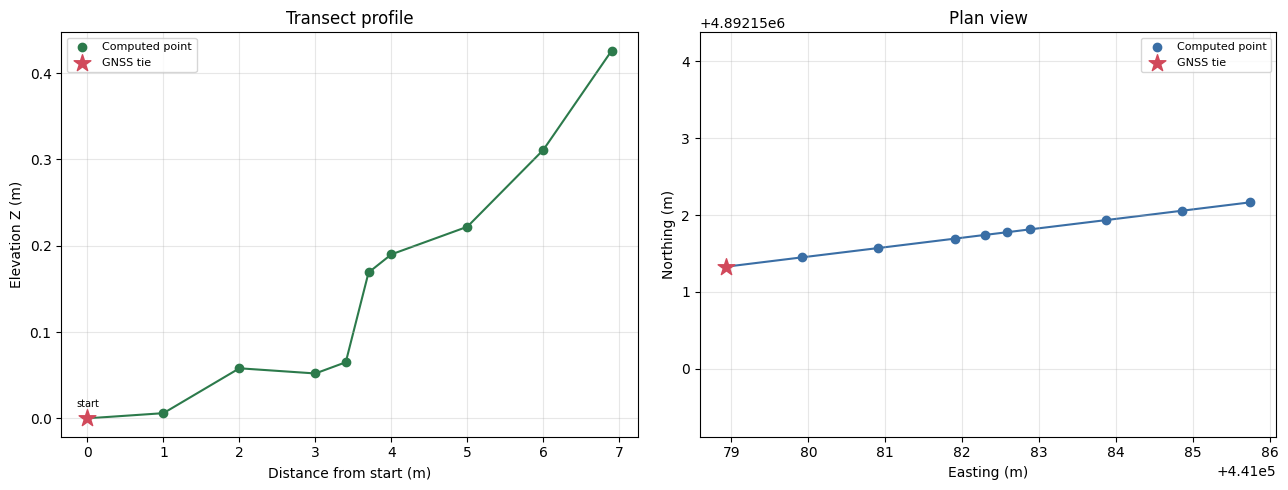

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ties = results[results["is_gnss_tie"]]
non_ties = results[~results["is_gnss_tie"]]

# Profile view
ax = axes[0]
ax.plot(results["tape_distance_m"], results["Z_m"], "-", color="#2c7a4b", zorder=1)
ax.scatter(non_ties["tape_distance_m"], non_ties["Z_m"], color="#2c7a4b", zorder=2, label="Computed point")
ax.scatter(ties["tape_distance_m"], ties["Z_m"], color="#d1495b", marker="*", s=160, zorder=3, label="GNSS tie")
for _, row in results.iterrows():
    if row["label"]:
        ax.annotate(row["label"], (row["tape_distance_m"], row["Z_m"]),
                    textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center")
ax.set_xlabel("Distance from start (m)")
ax.set_ylabel("Elevation Z (m)")
ax.set_title("Transect profile")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plan view
ax = axes[1]
ax.plot(results["X_utm_m"], results["Y_utm_m"], "-", color="#3a6ea5", zorder=1)
ax.scatter(non_ties["X_utm_m"], non_ties["Y_utm_m"], color="#3a6ea5", zorder=2, label="Computed point")
ax.scatter(ties["X_utm_m"], ties["Y_utm_m"], color="#d1495b", marker="*", s=160, zorder=3, label="GNSS tie")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Plan view")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Save results to Drive

Writes into `<DRIVE_FOLDER>/<input CSV name without extension>/`, next to
the input CSV:
- `<base_name>_topography.csv` — the results table
- `<base_name>_profile_plan.png` — the profile + plan-view plot
- `<base_name>_topography.geojson` — the same points (plus a line joining
  them, in order) as GeoJSON, with coordinates in **UTM meters** (the same
  projected CRS used throughout this notebook), not lon/lat.

> **Note on CRS:** the GeoJSON spec (RFC 7946) technically requires
> coordinates in WGS84 lon/lat. Since projected UTM meters are more useful
> for on-the-ground transect work, this file instead carries a `"crs"`
> member naming the UTM EPSG code — desktop GIS tools (QGIS, ArcGIS Pro,
> GDAL/ogr2ogr) read this and place the points correctly. Strict
> RFC-7946-only web-mapping clients (e.g. some JS libraries that assume
> lon/lat unconditionally) will *not* honor it and would misplace the
> points — if you need a web-map-safe file, reproject to lon/lat first
> (`to_wgs84.transform(...)`, already used for the `lon`/`lat` columns in
> the results table above).

In [12]:
os.makedirs(output_dir, exist_ok=True)

csv_out = os.path.join(output_dir, f"{base_name}_topography.csv")
png_out = os.path.join(output_dir, f"{base_name}_profile_plan.png")
geojson_out = os.path.join(output_dir, f"{base_name}_topography.geojson")

results.to_csv(csv_out, index=False)
fig.savefig(png_out, dpi=150, bbox_inches="tight")


def build_geojson(df, epsg_utm):
    point_features = [
        {
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [row["X_utm_m"], row["Y_utm_m"], row["Z_m"]],
            },
            "properties": {
                "point_id": int(row["point_id"]),
                "tape_distance_m": float(row["tape_distance_m"]),
                "is_gnss_tie": bool(row["is_gnss_tie"]),
                "label": row["label"],
            },
        }
        for _, row in df.iterrows()
    ]
    line_feature = {
        "type": "Feature",
        "geometry": {
            "type": "LineString",
            "coordinates": df[["X_utm_m", "Y_utm_m", "Z_m"]].to_numpy().tolist(),
        },
        "properties": {"name": f"{base_name}_transect_line"},
    }
    return {
        "type": "FeatureCollection",
        "crs": {
            "type": "name",
            "properties": {"name": f"urn:ogc:def:crs:EPSG::{epsg_utm}"},
        },
        "features": point_features + [line_feature],
    }


with open(geojson_out, "w") as f:
    json.dump(build_geojson(results, epsg_utm), f, indent=2)

print(f"Saved:\n  {csv_out}\n  {png_out}\n  {geojson_out}")

Saved:
  /content/drive/Othercomputers/My Mac/Documents/GitHub/seastrong-field-tools/Mangroves_topography/transect_demo/transect_demo_topography.csv
  /content/drive/Othercomputers/My Mac/Documents/GitHub/seastrong-field-tools/Mangroves_topography/transect_demo/transect_demo_profile_plan.png
  /content/drive/Othercomputers/My Mac/Documents/GitHub/seastrong-field-tools/Mangroves_topography/transect_demo/transect_demo_topography.geojson
